In [1]:
import pandas as pd

In [2]:
import numpy as np

In [4]:
df=pd.read_excel('Zomato.xlsx')

In [5]:
df

,online_order,book_table,rate,votes,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Yes,Yes,4.1,775,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Yes,No,4.1,787,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,Yes,No,3.8,918,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,No,No,3.7,88,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,No,No,3.8,166,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...
7658,Yes,No,3.1,140,Casual Dining,"North Indian, Biryani, Andhra, Chinese",600,NaN,NaN
7659,Yes,Yes,3.9,143,Casual Dining,"Mangalorean, Seafood, South Indian",1000,Delivery,BTM
7660,Yes,Yes,4.3,2563,Bar,"Continental, Finger Food, North Indian, Chinese",1200,NaN,NaN
7661,Yes,Yes,3.9,160,"Casual Dining, Lounge","North Indian, Continental",900,Delivery,BTM


In [6]:
df.shape

(7663, 9)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7663 entries, 0 to 7662
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   online_order                 7663 non-null   str    
 1   book_table                   7663 non-null   str    
 2   rate                         7663 non-null   float64
 3   votes                        7663 non-null   int64  
 4   rest_type                    7629 non-null   str    
 5   cuisines                     7661 non-null   str    
 6   approx_cost(for two people)  7663 non-null   int64  
 7   listed_in(type)              7088 non-null   str    
 8   listed_in(city)              7088 non-null   str    
dtypes: float64(1), int64(2), str(6)
memory usage: 983.4 KB


In [8]:
df.columns

Index(['online_order', 'book_table', 'rate', 'votes', 'rest_type', 'cuisines',
       'approx_cost(for two people)', 'listed_in(type)', 'listed_in(city)'],
      dtype='str')

In [9]:
df.head()

,online_order,book_table,rate,votes,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Yes,Yes,4.1,775,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Yes,No,4.1,787,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,Yes,No,3.8,918,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,No,No,3.7,88,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,No,No,3.8,166,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari


In [10]:
df.tail()

,online_order,book_table,rate,votes,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
7658,Yes,No,3.1,140,Casual Dining,"North Indian, Biryani, Andhra, Chinese",600,NaN,NaN
7659,Yes,Yes,3.9,143,Casual Dining,"Mangalorean, Seafood, South Indian",1000,Delivery,BTM
7660,Yes,Yes,4.3,2563,Bar,"Continental, Finger Food, North Indian, Chinese",1200,NaN,NaN
7661,Yes,Yes,3.9,160,"Casual Dining, Lounge","North Indian, Continental",900,Delivery,BTM
7662,Yes,No,4.0,510,Casual Dining,"Chinese, Naga",750,Delivery,BTM


In [11]:
df.isnull().sum()

online_order                     0
book_table                       0
rate                             0
votes                            0
rest_type                       34
cuisines                         2
approx_cost(for two people)      0
listed_in(type)                575
listed_in(city)                575
dtype: int64

In [12]:
df = df.dropna()
df

,online_order,book_table,rate,votes,rest_type,cuisines,approx_cost(for two people),listed_in(type),listed_in(city)
0,Yes,Yes,4.1,775,Casual Dining,"North Indian, Mughlai, Chinese",800,Buffet,Banashankari
1,Yes,No,4.1,787,Casual Dining,"Chinese, North Indian, Thai",800,Buffet,Banashankari
2,Yes,No,3.8,918,"Cafe, Casual Dining","Cafe, Mexican, Italian",800,Buffet,Banashankari
3,No,No,3.7,88,Quick Bites,"South Indian, North Indian",300,Buffet,Banashankari
4,No,No,3.8,166,Casual Dining,"North Indian, Rajasthani",600,Buffet,Banashankari
...,...,...,...,...,...,...,...,...,...
7656,Yes,No,4.0,118,Casual Dining,"Chinese, Thai",400,Delivery,BTM
7657,Yes,No,3.9,88,Quick Bites,Fast Food,250,Delivery,BTM
7659,Yes,Yes,3.9,143,Casual Dining,"Mangalorean, Seafood, South Indian",1000,Delivery,BTM
7661,Yes,Yes,3.9,160,"Casual Dining, Lounge","North Indian, Continental",900,Delivery,BTM


In [13]:
x = df.iloc[:, [2, 3, 6]].values
x

array([[   4.1,  775. ,  800. ],
       [   4.1,  787. ,  800. ],
       [   3.8,  918. ,  800. ],
       ...,
       [   3.9,  143. , 1000. ],
       [   3.9,  160. ,  900. ],
       [   4. ,  510. ,  750. ]], shape=(7055, 3))

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

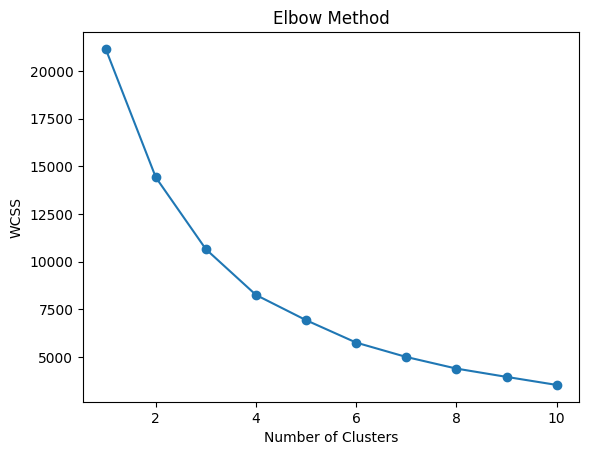

In [15]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42, n_init=350)
    km.fit(x)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [16]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=350)
y_kmeans = kmeans.fit_predict(x)

In [18]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
x2d = pca.fit_transform(x)

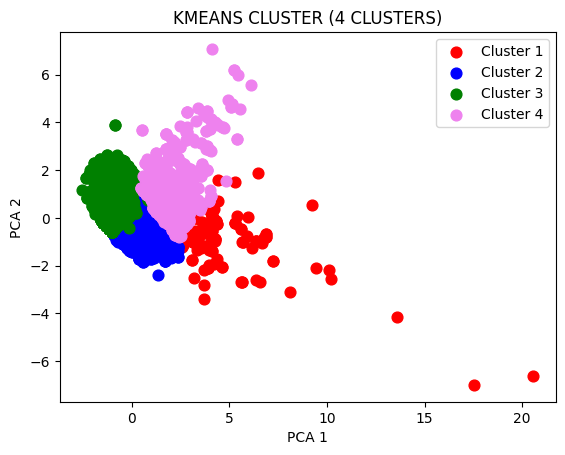

In [19]:
plt.scatter(x2d[y_kmeans==0, 0], x2d[y_kmeans==0, 1], s=60, c='red',    label='Cluster 1')
plt.scatter(x2d[y_kmeans==1, 0], x2d[y_kmeans==1, 1], s=60, c='blue',   label='Cluster 2')
plt.scatter(x2d[y_kmeans==2, 0], x2d[y_kmeans==2, 1], s=60, c='green',  label='Cluster 3')
plt.scatter(x2d[y_kmeans==3, 0], x2d[y_kmeans==3, 1], s=60, c='violet', label='Cluster 4')
plt.title('KMEANS CLUSTER (4 CLUSTERS)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.show()

In [20]:
df = df.copy()  # ensure it's not a slice

df.loc[:, 'cluster'] = y_kmeans

cluster_summary = df.groupby('cluster')[['rate', 'votes', 'approx_cost(for two people)']].mean().round(2)

print(cluster_summary)

         rate    votes  approx_cost(for two people)
cluster                                            
0        4.29  3105.06                      1112.41
1        3.86   190.25                       451.35
2        3.20    56.69                       412.94
3        4.04   522.95                      1498.92


In [21]:
import pickle

# Save KMeans model
with open('kmeans_model.pkl', 'wb') as f:
    pickle.dump(kmeans, f)

# Save Scaler (if used)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save PCA (if used)
with open('pca.pkl', 'wb') as f:
    pickle.dump(pca, f)